# CropHarvest: EDA

**One sample = one pixel**. A 12-month multi-sensor pixel time series with no spatial context.
No image patches, no neighbourhood — every label is a single isolated pixel over 12 months.


## Setup

In [83]:
from pathlib import Path
import glob, json
import numpy as np
import matplotlib.pyplot as plt

# find the repo root by walking up to the folder that has data/
REPO = Path.cwd()
while not (REPO / 'data').exists() and REPO != REPO.parent:
    REPO = REPO.parent
print('repo:', REPO)

CH = REPO / 'data' / 'input' / 'benchmarks' / 'cropharvest'
ARRAYS = CH / 'features' / 'arrays'
files = sorted(glob.glob(str(ARRAYS / '*.h5')))
print(len(files), 'CropHarvest field files')

repo: /Users/akshithchowdary/Developer/Projects/org/abe/robustness
67693 CropHarvest field files


## Raw layout of one sample

Each `.h5` holds one `(12, 18)` array: 12 monthly timesteps by 18 raw bands in this column order:

| idx | Band | Source | Used by code? |
|:---:|------|--------|:-------------:|
| 0 | VV | Sentinel-1 SAR (C-band, VV pol) | S1 |
| 1 | VH | Sentinel-1 SAR (C-band, VH pol) | S1 |
| 2 | B2 | Sentinel-2 MSI (Blue, 10m) | S2 |
| 3 | B3 | Sentinel-2 MSI (Green, 10m) | S2 |
| 4 | B4 | Sentinel-2 MSI (Red, 10m) | S2 |
| 5 | B5 | Sentinel-2 MSI (Red Edge 1, 20m) | S2 |
| 6 | B6 | Sentinel-2 MSI (Red Edge 2, 20m) | S2 |
| 7 | B7 | Sentinel-2 MSI (Red Edge 3, 20m) | S2 |
| 8 | B8 | Sentinel-2 MSI (NIR, 10m) | S2 |
| 9 | B8A | Sentinel-2 MSI (Narrow NIR, 20m) | S2 |
| 10 | B9 | Sentinel-2 MSI (Water vapour, 60m) | Skipped |
| 11 | B11 | Sentinel-2 MSI (SWIR 1, 20m) | S2 |
| 12 | B12 | Sentinel-2 MSI (SWIR 2, 20m) | S2 |
| 13 | temperature_2m | ERA5 climate reanalysis (2m air temp, K) | Climate |
| 14 | total_precipitation | ERA5 climate reanalysis (m) | Climate |
| 15 | elevation | SRTM Digital Elevation Model (m) | Climate |
| 16 | slope | SRTM-derived slope (degrees) | Dropped |
| 17 | NDVI | Computed from B4 & B8: `(B8-B4)/(B8+B4)` | S2 |

Band order per `cropharvest/bands.py`: DYNAMIC (S1 + S2 + ERA5) minus B1/B10 + STATIC (SRTM) + NDVI. Indices 10 (B9) and 16 (slope) are present in the raw `.h5` but ignored by the code's `CH_*_IDXS` constants.

file: 0_brazil-non-crop.h5 | shape: (12, 18)
dataset: brazil-non-crop | is_crop: 0 | lat/lon: -12.143 -44.99


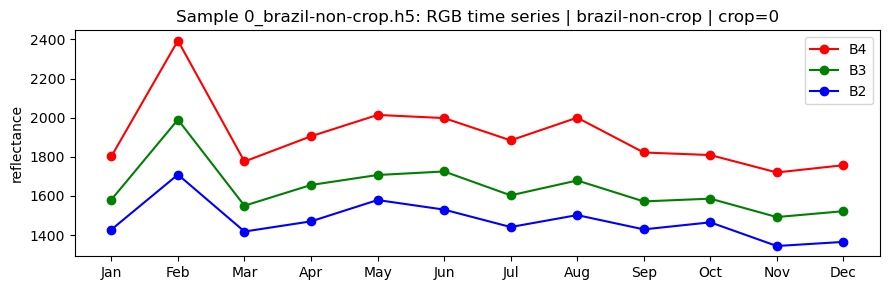

In [84]:
import h5py
# pick one field and read its raw (12, 18) array
path = files[0]
with h5py.File(path, 'r') as f:
    raw = np.asarray(f['array'], dtype=np.float32)
idx, dataset = Path(path).stem.split('_', 1)
print('file:', Path(path).name, '| shape:', raw.shape)

# look up this field's label + lat/lon in labels.geojson
feats = json.loads((CH / 'labels.geojson').read_text())['features']
label_of = {(int(g['properties']['index']), g['properties']['dataset']): g['properties'] for g in feats}
p = label_of[(int(idx), dataset)]
print('dataset:', dataset, '| is_crop:', p['is_crop'], '| lat/lon:', round(p['lat'], 3), round(p['lon'], 3))

# show the actual values for this one point: months as rows, bands as columns
BAND_NAMES = ['VV','VH','B2','B3','B4','B5','B6','B7','B8','B8A','B9','B11','B12',
              'temp_2m','precip','elevation','slope','NDVI']
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
t = pd.DataFrame(raw, index=months, columns=BAND_NAMES)
t.round(4)

# time-series of RGB bands across the 12 months
fig, ax = plt.subplots(figsize=(9, 3))
for band, color in zip(['B4', 'B3', 'B2'], ['red', 'green', 'blue']):
    ax.plot(months, t[band], marker='o', label=band, color=color)
ax.set_ylabel('reflectance')
ax.legend()
ax.set_title(f'Sample {Path(path).name}: RGB time series | {dataset} | crop={p["is_crop"]}')
plt.tight_layout(); plt.show()


## What this one field looks like over the year

The four modalities live on different scales, so each gets its own panel.

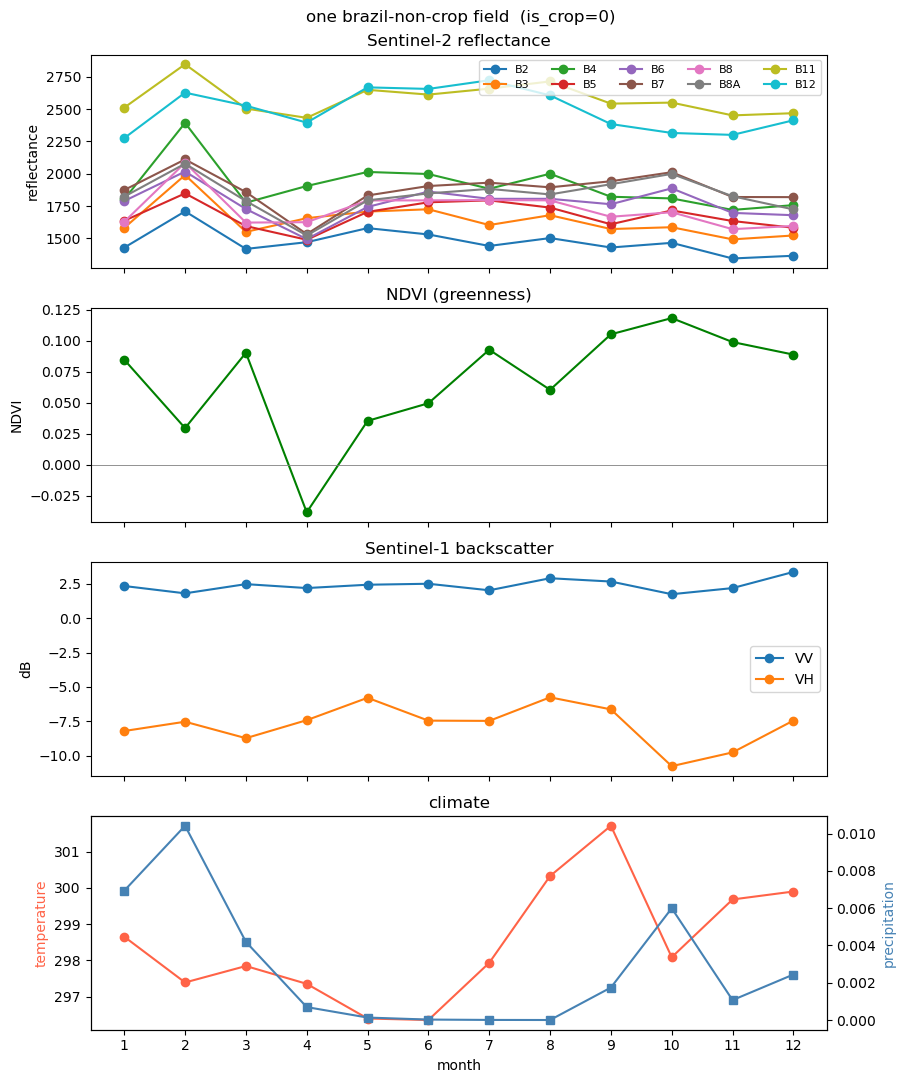

In [85]:
months = list(range(1, 13))
fig, ax = plt.subplots(4, 1, figsize=(9, 11), sharex=True)

# Sentinel-2 reflectance (cols 2..9, 11, 12)
s2_cols = [2, 3, 4, 5, 6, 7, 8, 9, 11, 12]
s2_names = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
for c, n in zip(s2_cols, s2_names):
    ax[0].plot(months, raw[:, c], marker='o', label=n)
ax[0].set_title('Sentinel-2 reflectance'); ax[0].set_ylabel('reflectance'); ax[0].legend(ncol=5, fontsize=8)

# NDVI (col 17), its own [-1, 1] scale
ax[1].plot(months, raw[:, 17], marker='o', color='green')
ax[1].set_title('NDVI (greenness)'); ax[1].set_ylabel('NDVI'); ax[1].axhline(0, color='grey', lw=0.6)

# Sentinel-1 radar (cols 0, 1) in dB
ax[2].plot(months, raw[:, 0], marker='o', label='VV')
ax[2].plot(months, raw[:, 1], marker='o', label='VH')
ax[2].set_title('Sentinel-1 backscatter'); ax[2].set_ylabel('dB'); ax[2].legend()

# climate: temperature + precipitation (cols 13, 14) on twin axes
ax[3].plot(months, raw[:, 13], marker='o', color='tomato', label='temperature')
ax[3].set_ylabel('temperature', color='tomato')
axb = ax[3].twinx()
axb.plot(months, raw[:, 14], marker='s', color='steelblue', label='precipitation')
axb.set_ylabel('precipitation', color='steelblue')
ax[3].set_title('climate'); ax[3].set_xlabel('month'); ax[3].set_xticks(months)

fig.suptitle(f"one {dataset} field  (is_crop={p['is_crop']})")
plt.tight_layout(); plt.show()

## A few fields side by side: crop vs non-crop

NDVI trajectory is the clearest single signal: crops green up and senesce, bare
/ non-crop land stays flatter. We grab a handful of each and overlay them.

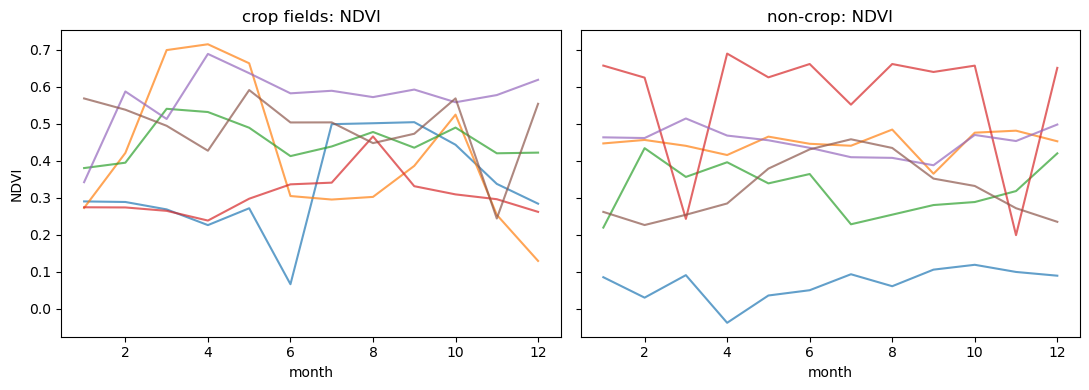

In [86]:
crop_paths, noncrop_paths = [], []
for path in files:
    i, ds = Path(path).stem.split('_', 1)
    key = (int(i), ds)
    if key not in label_of:
        continue
    bucket = crop_paths if label_of[key]['is_crop'] == 1 else noncrop_paths
    if len(bucket) < 6:
        bucket.append(path)
    if len(crop_paths) >= 6 and len(noncrop_paths) >= 6:
        break

fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for path in crop_paths:
    with h5py.File(path, 'r') as f:
        ax[0].plot(months, np.asarray(f['array'])[:, 17], alpha=0.7)
for path in noncrop_paths:
    with h5py.File(path, 'r') as f:
        ax[1].plot(months, np.asarray(f['array'])[:, 17], alpha=0.7)
ax[0].set_title('crop fields: NDVI'); ax[1].set_title('non-crop: NDVI')
ax[0].set_xlabel('month'); ax[1].set_xlabel('month'); ax[0].set_ylabel('NDVI')
plt.tight_layout(); plt.show()

## Dataset-level: label balance and source regions

Breakdown of source datasets that make up CropHarvest. The 25 rows in the CropHarvest paper's `datasets.md` collapse to 22 unique `<dataset>` strings because multiple rows from the same area share a label.

Sub-datasets: ['brazil-non-crop', 'central-asia', 'croplands', 'ethiopia', 'geowiki-landcover-2017', 'ile-de-france', 'kenya', 'kenya-non-crop', 'lem-brazil', 'mali', 'mali-non-crop', 'martinique-france', 'reunion-france', 'rwanda', 'rwanda-ceo', 'sudan', 'tanzania', 'togo', 'togo-eval', 'uganda', 'usa-kern', 'zimbabwe']

Number of sub-datasets: 22


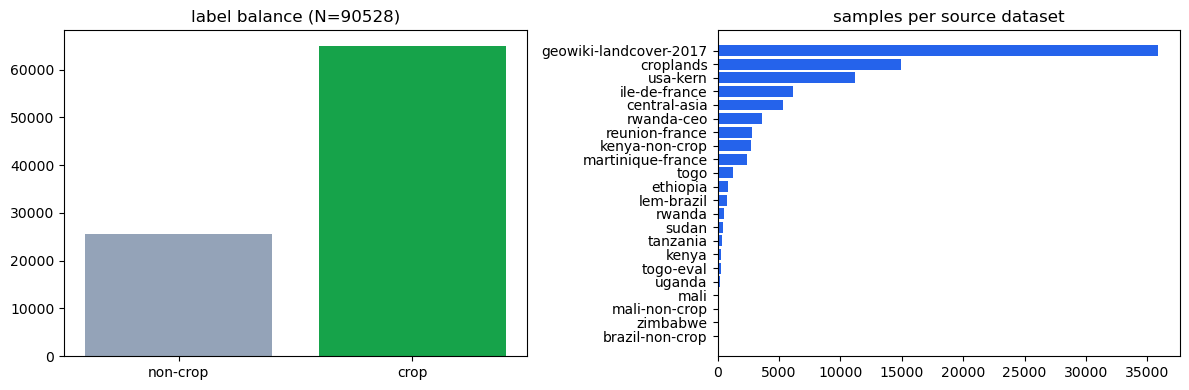

In [87]:
import collections
is_crop = [g['properties']['is_crop'] for g in feats]
datasets = [g['properties']['dataset'] for g in feats]
by_dataset = collections.Counter(datasets)

all_datasets = sorted(by_dataset.keys())
print('Sub-datasets:', all_datasets)
print(f'\nNumber of sub-datasets: {len(all_datasets)}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
vals, counts = np.unique(is_crop, return_counts=True)
ax[0].bar(['non-crop', 'crop'], counts, color=['#94a3b8', '#16a34a'])
ax[0].set_title(f'label balance (N={len(is_crop)})')
top = by_dataset.most_common()
ax[1].barh([k for k, _ in top][::-1], [v for _, v in top][::-1], color='#2563eb')
ax[1].set_title('samples per source dataset')
plt.tight_layout(); plt.show()


## Geography

Source datasets are geographically clustered, which is exactly why strict
holdout (train on some regions, test on a held-out one) is a hard, realistic test.

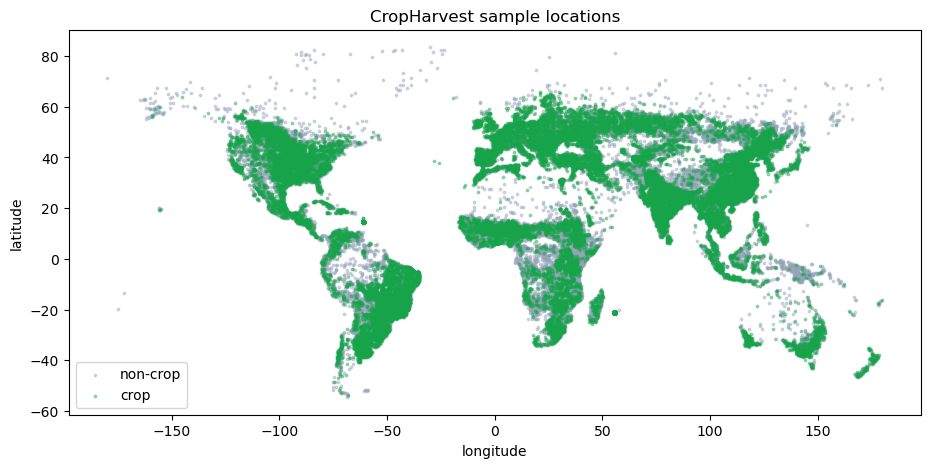

In [88]:
lat = np.array([g['properties']['lat'] for g in feats])
lon = np.array([g['properties']['lon'] for g in feats])
crop = np.array(is_crop)
plt.figure(figsize=(11, 5))
plt.scatter(lon[crop == 0], lat[crop == 0], s=3, c='#94a3b8', label='non-crop', alpha=0.4)
plt.scatter(lon[crop == 1], lat[crop == 1], s=3, c='#16a34a', label='crop', alpha=0.4)
plt.xlabel('longitude'); plt.ylabel('latitude'); plt.legend(); plt.title('CropHarvest sample locations')
plt.show()

### Source-origin mapping: datasets.md to GeoJSON dataset string

The 25 entries in the official `datasets.md` collapse to 22 unique dataset strings. Multiple rows from the same area share a `dataset` label in the GeoJSON:

| # | Source (Org/Paper) | Area | Labels | Type | GeoJSON dataset |
|---|-------------------|------|-------:|------|-----------------|
| 1 | NASA Harvest | Rwanda | 3,600 | Binary | rwanda |
| 2 | NASA Harvest | Kenya | 2,704 | Binary | kenya |
| 3 | NASA Harvest | Ethiopia | 830 | Binary | ethiopia |
| 4 | NASA Harvest | Sudan | 422 | Binary | sudan |
| 5 | NASA Harvest | Mali | 142 | Binary | mali |
| 6 | NASA Harvest | Brazil | 36 | Binary | brazil-non-crop |
| 7 | NASA Harvest | Tanzania | 2,400 | Binary | tanzania |
| 8 | Kerner et al. 2020 | Togo | 1,582 | Binary | togo |
| 9 | IGN RPG | France (Ile-de-France) | 6,184 | Multi | ile-de-france |
| 10 | IGN RPG | France (Reunion) | 2,776 | Multi | reunion-france |
| 11 | IGN RPG | France (Martinique) | 2,421 | Multi | martinique-france |
| 12 | Geo-Wiki crowd-sourced | Global | 35,866 | Binary | geowiki-landcover-2017 |
| 13 | NASA GFSAD | Global | 14,976 | Multi | croplands |
| 14 | AAFC Canada | Canada | 9,088 | Multi | usa-kern (anomalous) |
| 15 | Remelgado et al. 2020 | Uzbekistan, Tajikistan | 5,302 | Multi | central-asia |
| 16 | DENETHOR | Germany | 2,550 | Multi | (not in this export) |
| 17 | LEM+ (Oldoni et al. 2020) | Brazil | 800 | Multi | lem-brazil |
| 18 | Great African Food Co. | Tanzania | 392 | Multi | (merged into tanzania) |
| 19 | PlantVillage | Kenya | 319 | Multi | (merged into kenya) |
| 20 | Dalberg Data Insights | Uganda | 233 | Multi | uganda |
| 21 | Nakalembe et al. 2022 | Tanzania | 800 | Multi | (merged into tanzania) |
| 22 | Harvest Partner | Mali | 148 | Multi | (merged into mali) |
| 23 | Harvest Partner | Mali | 1,506 | Multi | (merged into mali) |
| 24 | FEWS NET | Zimbabwe | 49 | Multi | zimbabwe |
| 25 | JOLIVOT et al. 2021 | Global | 13,005 | Multi | (merged into croplands) |

Merged rows: Global (rows 12,13,25) collapses into `croplands` + `geowiki-landcover-2017`. Mali (rows 5,22,23) and Tanzania (rows 7,18,21) each collapse to one. Some entries (DENETHOR Germany) may be absent depending on the Zenodo export version.

## Takeaways

One sample is a 12-step multi-sensor pixel time series, label = `is_crop`. NDVI carries most of the visible crop signal; S1 and climate add context. Source `dataset` is the geographic holdout group (strict transfer).